Organização dos dados

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('dados/banking.db')

financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']

query = f"""
SELECT 
    {', '.join(financial_indicators)} 
FROM    
    balancetes_media_ano
WHERE 
    cnpj IN (
        SELECT cnpj
        FROM balancetes_bancos_sociedades_media_ano
        GROUP BY ano, cnpj
    );"""

df = pd.read_sql_query(query, conn)

conn.close()

df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

colunas_para_limpar = ['nome_conta', 'taxonomia']

for col in colunas_para_limpar:
    df[col] = (df[col]
               .str.lower()
               .str.normalize('NFD')
               .str.replace(r'[\u0300-\u036f]', '', regex=True))

# Padronizando nomes
df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"

# Conta duplicada
df = df[df['conta'] != 88000008]
df = df[df['conta'] != 47100004]
df = df[df['conta'] != 51100007]
df = df[df['conta'] != 78100004]
df = df[df['conta'] != 61000001]

mapa_contas = (
    df.groupby('conta')['nome_conta']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

novo_mapeamento = {}

for conta, nome in mapa_contas.items():
    conta_str = str(conta) # Garante que podemos verificar o início
    
    if conta_str.startswith('1'):
        novo_nome = f"ativo realizavel - {nome}"
    elif conta_str.startswith('2'):
        novo_nome = f"ativo permanente - {nome}"
    elif conta_str.startswith('3'):
        novo_nome = f"compensacao ativa - {nome}"
    elif conta_str.startswith('4'):
        novo_nome = f"passivo exigivel - {nome}"
    elif conta_str.startswith('6'):
        novo_nome = f"patrimonio liquido - {nome}"
    elif conta_str.startswith('7'):
        novo_nome = f"resultado credor - {nome}"
    elif conta_str.startswith('8'):
        novo_nome = f"resultado devedor - {nome}"
    elif conta_str.startswith('9'):
        novo_nome = f"compensacao passiva - {nome}"
    else:
        novo_nome = nome # Mantém o original se não houver regra
        
    novo_mapeamento[conta] = novo_nome

mapa_contas = novo_mapeamento

df = df.pivot(
    index=['ano', 'cnpj', 'nome', 'taxonomia'],
    columns='conta',
    values='saldo'
).reset_index()
df['ano'] = df['ano'].astype(int)

# Valor mínimo da conta operações de crédito
df = df[df[16000001] > 1000000]
#df = df[df['taxonomia'] != 'sociedade de credito ao microempreendedor']

df_original = df.copy()

# Dividindo os valores pelo Ativo Total (39999993)
colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia', 39999993]]
for col in colunas_a_dividir:
    df[col] = df[col] / df[39999993]
df.drop(columns=[39999993, 99999995], inplace=True)
df_filtrado = df

df_original = df_original.rename(columns=novo_mapeamento)
df = df.rename(columns=novo_mapeamento)

In [2]:
# Eliminando colunas esparsas

# 1. Calcular a porcentagem de nulos em cada coluna
#esparsidade = df.isnull().sum() / len(df)
esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
# 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
print(f"Colunas com > 10% de nulos: {sum(esparsidade > 0.10)}")
print(f"Colunas com > 20% de nulos: {sum(esparsidade > 0.20)}")
print(f"Colunas com > 30% de nulos: {sum(esparsidade > 0.30)}")

# 3. Definir o limiar
limiar_corte = 0.30

# Identificar colunas a serem removidas
colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
# 4. Criar o novo dataset filtrado
df_filtrado = df.drop(columns=colunas_para_remover)
df_original = df_original.drop(columns=colunas_para_remover)

print(f"\nDimensão original: {df.shape[1]} colunas")
print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
df_filtrado.fillna(0, inplace=True)

taxonomias = df_filtrado['taxonomia'].unique()

#df_filtrado['taxonomia_agrupada'] = df_filtrado['taxonomia']

# Se a taxonomia começar com "banco", vira apenas "banco"
# Usamos case=False para evitar problemas com maiúsculas/minúsculas
'''mask = df_filtrado['taxonomia'].str.startswith('banco', na=False)
df_filtrado.loc[mask, 'taxonomia_agrupada'] = 'bancos'
df_original.loc'''

Colunas com > 10% de nulos: 171
Colunas com > 20% de nulos: 158
Colunas com > 30% de nulos: 146

Dimensão original: 207 colunas
Dimensão após corte de esparsidade: 60 colunas


"mask = df_filtrado['taxonomia'].str.startswith('banco', na=False)\ndf_filtrado.loc[mask, 'taxonomia_agrupada'] = 'bancos'\ndf_original.loc"

<Axes: xlabel='conta', ylabel='conta'>

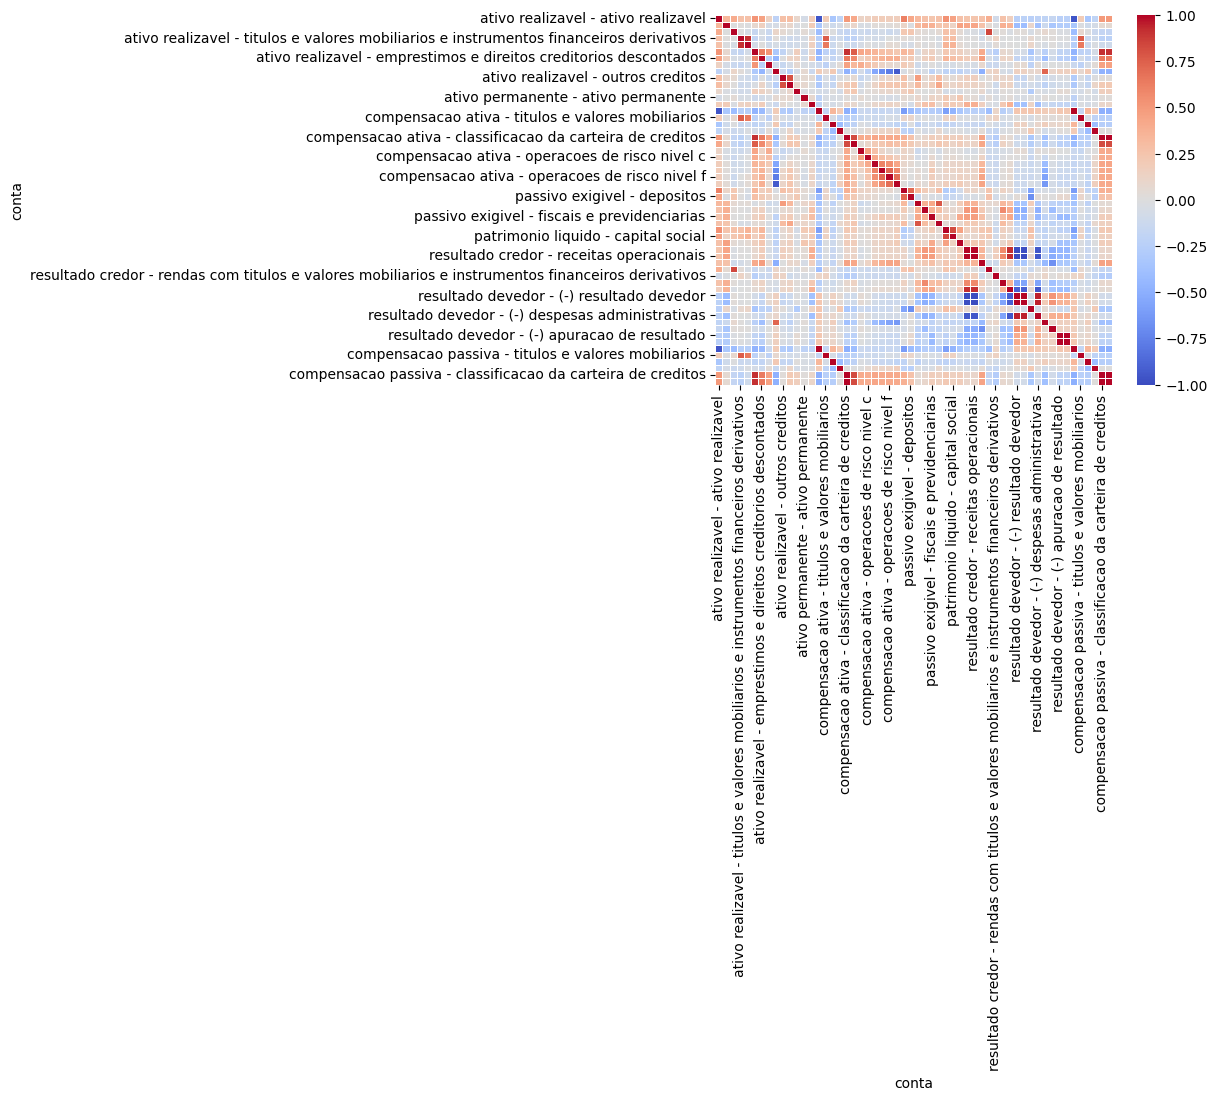

In [3]:
# Normalização dos dados

import numpy as np
import seaborn as sns

X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'], axis=1)
variaveis = pd.DataFrame({'Contas': [col for col in X.columns]})
# X.dropna(axis=1, inplace=True)
X.fillna(0, inplace=True)

corr_matrix = X.corr(method='pearson')

# Usar um heatmap do seaborn
# Cmap='coolwarm' é ótimo, pois destaca cores diferentes para correlação positiva e negativa
sns.heatmap(
    corr_matrix, 
    annot=False,            # Não mostrar os números (seria ilegível com 159)
    cmap='coolwarm', 
    fmt=".2f",              # Formato de duas casas decimais
    linewidths=.5,          # Linhas entre as células
    vmin=-1, vmax=1         # Definir escala de -1 a 1
)


In [4]:
# Análise de Correlação para Identificar Variáveis Redundantes

# 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
corr_matrix_abs = corr_matrix.abs()

# 2. Selecionar apenas o triângulo superior da matriz
# Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 3. Definir o Limiar de Corte (Threshold)
# 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
threshold = 0.95

# Encontrar colunas que têm correlação > threshold com qualquer outra coluna
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
print(to_drop)

# Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
X.drop(columns=to_drop, inplace=True)

from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import RobustScaler
scaler = StandardScaler()
#scaler = RobustScaler()
X.columns = X.columns.astype(str)
colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
df_identificadores = df_filtrado[colunas_id]
X = df_filtrado.drop(columns=colunas_id, axis=1)
X_scaled = scaler.fit_transform(X)

# Optional: Convert back to a DataFrame for easier handling, using the original column names
#X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)



--- Contas Redundantes a Descartar (Correlação > 0.95) ---
Número de variáveis sugeridas para remoção: 12
['compensacao ativa - compensacao ativa', 'resultado credor - receitas operacionais', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'resultado devedor - (-) despesas administrativas', 'resultado devedor - (-) imposto de renda', 'compensacao passiva - compensacao passiva', 'compensacao passiva - titulos e valores mobiliarios', 'compensacao passiva - custodia de valores', 'compensacao passiva - controle', 'compensacao passiva - classificacao da carteira de creditos', 'compensacao passiva - operacoes de creditos e arrendamento mercantil']


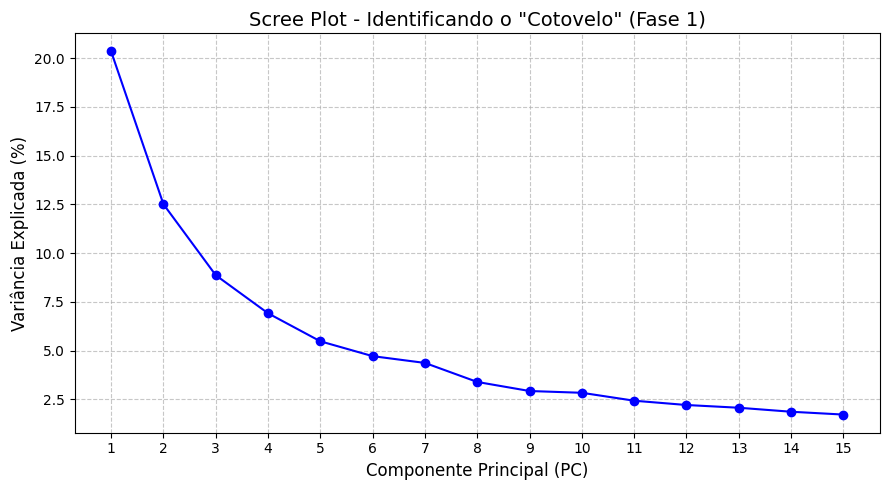

In [5]:
#Primeira aplicação do PCA para identificar os outliers

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Rodamos o PCA com os primeiros 15 componentes apenas para ver a curva de queda
pca_diagnostico = PCA(n_components=15, random_state=42)
pca_diagnostico.fit(X_scaled)

# 2. Extraímos a variância INDIVIDUAL de cada componente (em porcentagem)
variancia_individual = pca_diagnostico.explained_variance_ratio_ * 100

# 3. Desenhamos o Gráfico de Cotovelo
plt.figure(figsize=(9, 5))
plt.plot(range(1, 16), variancia_individual, marker='o', linestyle='-', color='b')

plt.title('Scree Plot - Identificando o "Cotovelo" (Fase 1)', fontsize=14)
plt.xlabel('Componente Principal (PC)', fontsize=12)
plt.ylabel('Variância Explicada (%)', fontsize=12)
plt.xticks(range(1, 16)) # Garante que todos os números de 1 a 15 apareçam no eixo X
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separar os identificadores e a matriz numérica (X)
colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']

# Isola os identificadores para guardarmos
df_identificadores = df_filtrado[colunas_id]

# Parâmetros da Fase 1 (Ajuste os desvios e componentes conforme o seu Scree Plot)
limite_desvios = 4
n_componentes_fase1 = 4

bancos_normais_list = []
bancos_outliers_list = []
historico_variancia = []

# 2. Iniciar a "Máquina do Tempo" (Loop ano a ano)
for ano_atual in df_identificadores['ano'].unique():
    
    # Filtrar o ano atual tanto na matriz X quanto nos identificadores
    mascara_ano = (df_identificadores['ano'] == ano_atual)
    X_ano = X[mascara_ano]
    id_ano = df_identificadores[mascara_ano]
    
    # Se por acaso algum ano não tiver dados, pula para o próximo
    if X_ano.empty:
        continue
        
    # Padronizar os dados EXCLUSIVAMENTE com a média deste ano
    scaler_ano = StandardScaler()
    X_ano_padronizado = scaler_ano.fit_transform(X_ano)
    
    # Rodar o PCA diagnóstico para este ano
    pca_ano = PCA(n_components=n_componentes_fase1, random_state=42)
    pca_array_ano = pca_ano.fit_transform(X_ano_padronizado)
    df_pca_ano = pd.DataFrame(pca_array_ano, index=X_ano.index)

    variancia_percentual = pca_ano.explained_variance_ratio_ * 100
    
    # Salvar os dados deste ano no nosso rastreador
    historico_variancia.append({
        'Ano': ano_atual,
        'PC1 (%)': np.round(variancia_percentual[0], 2),
        'PC2 (%)': np.round(variancia_percentual[1], 2),
        'PC3 (%)': np.round(variancia_percentual[2], 2),
        'PC4 (%)': np.round(variancia_percentual[3], 2),
        'Acumulada Fase 1 (%)': np.round(np.sum(variancia_percentual), 2)
    })
    
    # Calcular o Z-score e achar os outliers deste ano específico
    z_scores_ano = np.abs((df_pca_ano - df_pca_ano.mean()) / df_pca_ano.std())
    mascara_outliers_ano = (z_scores_ano > limite_desvios).any(axis=1)
    
    # Reconstruir o dataframe do ano (colando as IDs de volta no X original)
    df_completo_ano = pd.concat([id_ano, X_ano], axis=1)
    
    # Separar os normais das anomalias
    outliers_do_ano = df_completo_ano[mascara_outliers_ano]
    normais_do_ano = df_completo_ano[~mascara_outliers_ano]
    
    # Guardar os resultados do ano nas listas
    bancos_outliers_list.append(outliers_do_ano)
    bancos_normais_list.append(normais_do_ano)

# 3. Costurar o resultado final
df_outliers_final = pd.concat(bancos_outliers_list)
df_normais_final = pd.concat(bancos_normais_list)

df_filtrado = df_normais_final
colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
df_identificadores = df_filtrado[colunas_id]
X = df_filtrado.drop(columns=colunas_id, axis=1)
X_scaled = scaler.fit_transform(X)
df_original = df_original.loc[df_original.index.isin(df_filtrado.index)]

df_variancia_historica = pd.DataFrame(historico_variancia).sort_values('Ano').reset_index(drop=True)

print("--- Evolução da Variância Explicada no SFN (Ano a Ano) ---")
print(df_variancia_historica.to_string())


--- Evolução da Variância Explicada no SFN (Ano a Ano) ---
     Ano  PC1 (%)  PC2 (%)  PC3 (%)  PC4 (%)  Acumulada Fase 1 (%)
0   2010    23.64    10.80     9.60     7.15                 51.19
1   2011    23.48    11.27    10.68     7.28                 52.71
2   2012    24.68    12.71     9.62     7.43                 54.44
3   2013    23.78    12.47    10.13     6.42                 52.81
4   2014    24.02    12.98     9.50     6.59                 53.09
5   2015    22.40    12.66     9.94     7.54                 52.54
6   2016    19.67    12.92     9.69     7.70                 49.97
7   2017    23.12    12.49     8.84     7.51                 51.96
8   2018    24.72    12.92     8.59     7.20                 53.42
9   2019    26.46    14.16     8.49     7.22                 56.32
10  2020    24.15    13.97     8.44     6.94                 53.49
11  2021    24.81    11.62     9.40     7.53                 53.35
12  2022    20.39    12.30     9.03     7.62                 49.34
13 

In [7]:
ano_alvo = 2018
df_fase1 = df_filtrado[df_filtrado['ano'] <= ano_alvo]
#colunas_indice = ['ano', 'nome', 'taxonomia']
#df_fase1 = df_fase1.drop(columns=colunas_indice, axis=1)
#df_fase1 = df_original_fase1.groupby(['cnpj']).mean().reset_index()

X = df_fase1.drop(columns=colunas_id, axis=1)
#X = X.groupby(['cnpj']).mean().reset_index()
X_scaled = scaler.fit_transform(X)


In [8]:
# Analisando bancos atípicos (Outliers) usando o PCA
'''
componentes_pca_outliers = 5
pca_final = PCA(n_components=componentes_pca_outliers) # num de componentes do PCA
X_pca = pca_final.fit_transform(X_scaled)

# 1. Definir o limite de desvios padrões (3 é o padrão de mercado)
limite_desvios = 4

df_pca = pd.DataFrame(X_pca)
# df_pca = df_pca[[0, 1]]
# 3. Calcular a distância em Desvios Padrões (Z-score absoluto)
# A fórmula é: | (valor - média) / desvio_padrao |
z_scores = np.abs((df_pca - df_pca.mean()) / df_pca.std())

# 4. Criar uma "máscara" (Filtro)
# A função .any(axis=1) verifica se a instituição estourou o limite em PELO MENOS UM dos componentes
mascara_outliers = (z_scores > limite_desvios).any(axis=1)

# 5. Extrair os Outliers (Os bancos atípicos)
bancos_outliers = df_filtrado[mascara_outliers.values]

# 6. Extrair os Inliers (A base limpa para o K-Means)
bancos_normais = df_filtrado[~mascara_outliers.values] # O símbolo ~ inverte o filtro

df_filtrado = df_filtrado[~mascara_outliers.values]
X_scaled = X_scaled[~mascara_outliers]'''

'\ncomponentes_pca_outliers = 5\npca_final = PCA(n_components=componentes_pca_outliers) # num de componentes do PCA\nX_pca = pca_final.fit_transform(X_scaled)\n\n# 1. Definir o limite de desvios padrões (3 é o padrão de mercado)\nlimite_desvios = 4\n\ndf_pca = pd.DataFrame(X_pca)\n# df_pca = df_pca[[0, 1]]\n# 3. Calcular a distância em Desvios Padrões (Z-score absoluto)\n# A fórmula é: | (valor - média) / desvio_padrao |\nz_scores = np.abs((df_pca - df_pca.mean()) / df_pca.std())\n\n# 4. Criar uma "máscara" (Filtro)\n# A função .any(axis=1) verifica se a instituição estourou o limite em PELO MENOS UM dos componentes\nmascara_outliers = (z_scores > limite_desvios).any(axis=1)\n\n# 5. Extrair os Outliers (Os bancos atípicos)\nbancos_outliers = df_filtrado[mascara_outliers.values]\n\n# 6. Extrair os Inliers (A base limpa para o K-Means)\nbancos_normais = df_filtrado[~mascara_outliers.values] # O símbolo ~ inverte o filtro\n\ndf_filtrado = df_filtrado[~mascara_outliers.values]\nX_scaled = 

Redução de dimensionalidade

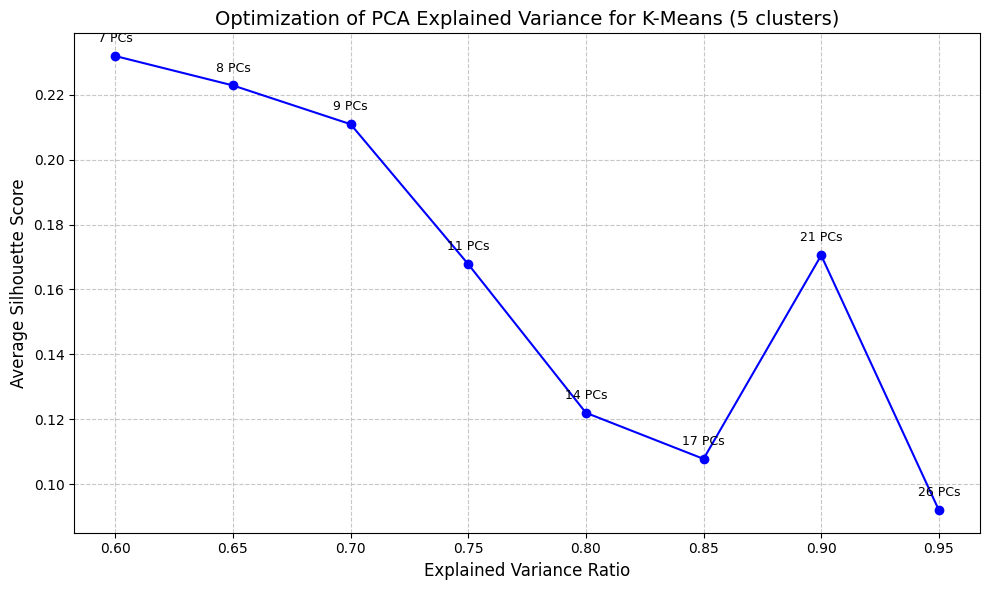

In [13]:
# Análise de Silhueta x Variância do PCA para Otimizar o K-Means

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

numero_de_clusters = 5

# 1. Definimos a grade de variâncias que queremos testar (de 60% a 95%, pulando de 5 em 5)
niveis_variancia = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

# Listas vazias para guardar os resultados
escores_silhueta = []
qnt_componentes = []

# 2. O Loop de Experimentação
for var in niveis_variancia:
    # A. Roda o PCA para o nível de variância atual da repetição
    pca_test_silhoutte = PCA(n_components=var, random_state=42)
    dados_pca = pca_test_silhoutte.fit_transform(X_scaled)
    
    # Guarda quantos componentes o PCA precisou para atingir essa variância
    qnt_componentes.append(pca_test_silhoutte.n_components_)
    
    # B. Roda o K-Means nos dados reduzidos
    kmeans = KMeans(n_clusters=numero_de_clusters, random_state=42)
    kmeans.fit(dados_pca)
    
    # C. Calcula e guarda o Escore de Silhueta
    score = silhouette_score(dados_pca, kmeans.labels_)
    escores_silhueta.append(score)

# 3. Visualizando os Resultados
plt.figure(figsize=(10, 6))

# Plota a linha principal (Variância vs Silhueta)
plt.plot(niveis_variancia, escores_silhueta, marker='o', linestyle='-', color='b')

# Adiciona o número de componentes como rótulo em cada ponto para facilitar sua vida
for i, txt in enumerate(qnt_componentes):
    plt.annotate(f"{txt} PCs", (niveis_variancia[i], escores_silhueta[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title(f'Optimization of PCA Explained Variance for K-Means ({numero_de_clusters} clusters)', fontsize=14)
plt.xlabel('Explained Variance Ratio', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
# Criação do PCA Final com o Número de Componentes Otimizado

num_componentes_pca = 21
pca_final = PCA(n_components=num_componentes_pca) # num de componentes do PCA
X_pca = pca_final.fit_transform(X_scaled)

features = X.columns.tolist()

# Criar um DataFrame com os componentes principais de cada instituição
# Gerar dinamicamente os nomes das colunas: 'PC1', 'PC2', 'PC3', etc.
nomes_componentes = [f'PC{i+1}' for i in range(X_pca.shape[1])]


In [15]:
# Converter o array do PCA de volta para DataFrame do Pandas
df_pca_puro = pd.DataFrame(
    X_pca, 
    columns=nomes_componentes, 
    index=df_fase1.index # Mantém a mesma ordem das linhas original
)
df_var_pca = df_pca_puro.var()

# Colar os identificadores ao lado dos componentes
df_pca_valores = pd.concat([df_fase1[['ano', 'cnpj', 'nome']], df_pca_puro], axis=1)

# Criar um DataFrame com os pesos (Loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(num_componentes_pca)], 
    index=features
)

# Análise de Relevância dos Componentes do PCA
# 1. Extrair a porcentagem de relevância de CADA componente do PCA
relevancia_individual = pca_final.explained_variance_ratio_

# 2. Calcular a relevância ACUMULADA (soma progressiva)
relevancia_acumulada = np.cumsum(relevancia_individual)

# 3. Criar uma tabela para visualizar (DataFrame Pandas)
pca_relevancia = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(relevancia_individual))],
    'Variância Individual (%)': np.round(relevancia_individual * 100, 2),
    'Variância Acumulada (%)': np.round(relevancia_acumulada * 100, 2)
})

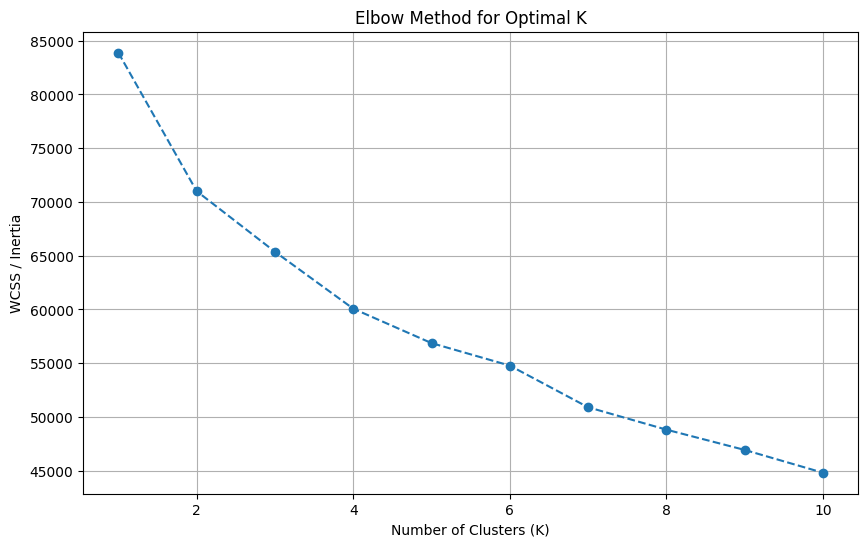

--- Estatística de Hartigan para Escolha de K ---
   K  Estatística_Hartigan  Redução_Percentual
0  2                  0.09                8.62
1  3                  0.09                8.81
2  4                  0.06                5.63
3  5                  0.04                3.82
4  6                  0.08                7.61
5  7                  0.04                4.27
6  8                  0.04                4.02
7  9                  0.05                4.73


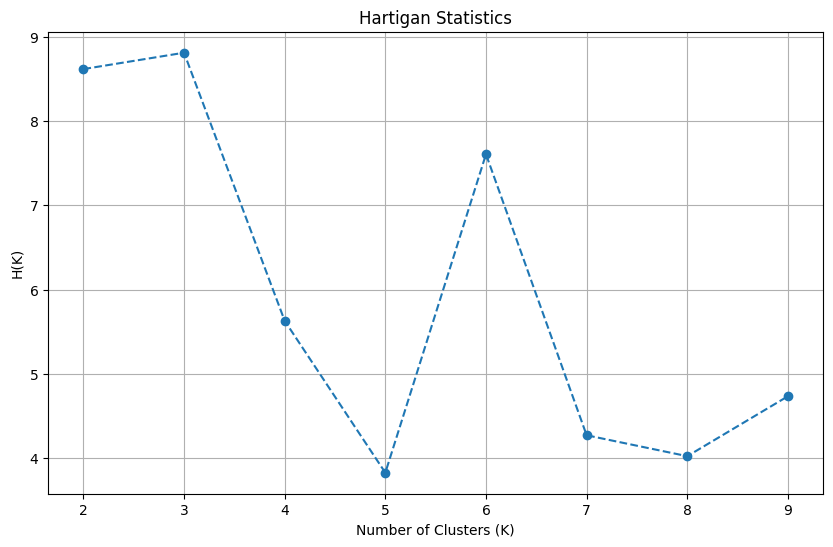

In [16]:
# Testes de número de clusters (K) para o K-Means

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the range of K to test (e.g., from 1 to 15 clusters)
max_k = 10
wcss = [] # Within-Cluster Sum of Squares

for i in range(1, max_k + 1):
    # Use n_init='auto' for robustness and random_state for reproducibility
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()

hartigan_stats = {}
max_k = len(wcss)

for k in range(2, max_k):
    wcss_k = wcss[k-1]
    wcss_k_plus_1 = wcss[k]

    hartigan = (wcss_k - wcss_k_plus_1) / wcss_k_plus_1
    
    hartigan_stats[k] = hartigan

hartigan_df = pd.DataFrame(
    list(hartigan_stats.items()), 
    columns=['K', 'Estatística_Hartigan']
)

hartigan_df['Redução_Percentual'] = hartigan_df['Estatística_Hartigan'] * 100

print("--- Estatística de Hartigan para Escolha de K ---")
print(hartigan_df.round(2))

plt.figure(figsize=(10, 6))
plt.plot(hartigan_df['K'], hartigan_df['Redução_Percentual'], marker='o', linestyle='--')
plt.title('Hartigan Statistics')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('H(K)')
plt.grid(True)
plt.show()

Criação e análises dos clusters

In [17]:
#Criação do modelo final de K-Means com o número de clusters otimizado

optimal_k = numero_de_clusters

# Initialize and train the final model
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
final_kmeans.fit(X_pca)

# Get the cluster labels for each bank
cluster_labels = final_kmeans.labels_

# Add the cluster labels to the original DataFrame
df_fase1['Cluster'] = cluster_labels
df_fase1.columns = df_fase1.columns.astype(str)
coluna_para_mover = df_fase1.pop('Cluster')
df_fase1.insert(4, 'Cluster', coluna_para_mover)

df_original_fase1 = df_original[df_original['ano'] <= ano_alvo]
df_original_fase1['Cluster'] = cluster_labels
df_original_fase1.columns = df_original_fase1.columns.astype(str)
coluna_para_mover = df_original_fase1.pop('Cluster')
df_original_fase1.insert(4, 'Cluster', coluna_para_mover) 

# Save the results to a new CSV or update the SQLite database
df_fase1[['cnpj', 'Cluster']].to_csv('bank_clusters.csv', index=False)

# Profile the clusters by calculating the mean of the original (unscaled) features for each cluster
cluster_profiles = df_fase1.groupby('Cluster')[X.columns].mean().sort_values(by='ativo realizavel - operacoes de credito', ascending=False)
#cluster_profiles.to_csv('cluster_profiles.csv', index=False)



/tmp/ipykernel_469282/985804479.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fase1['Cluster'] = cluster_labels
/tmp/ipykernel_469282/985804479.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_original_fase1['Cluster'] = cluster_labels


In [18]:
# Criar tabela de perfil dos clusters

print("\n--- Cluster Profiles (Centroid Means) ---")
print(cluster_profiles)

#df_fase1['ano'] = df_fase1['ano'].astype(int)

# Agrupa pelas três colunas e conta as ocorrências
contagem_clusters = df_fase1.groupby(['ano', 'taxonomia', 'Cluster']).size().reset_index(name='quantidade')

tabela_dinamica = contagem_clusters.pivot_table(
    index=['taxonomia', 'Cluster'], 
    columns='ano', 
    values='quantidade', 
    fill_value=0
)


--- Cluster Profiles (Centroid Means) ---
conta    ativo realizavel - ativo realizavel  \
Cluster                                        
2                                   0.348980   
0                                   0.328992   
3                                   0.264963   
1                                   0.159294   
4                                   0.313808   

conta    ativo realizavel - disponibilidades  \
Cluster                                        
2                                   0.006827   
0                                   0.002021   
3                                   0.001318   
1                                   0.001161   
4                                   0.005711   

conta    ativo realizavel - aplicacoes interfinanceiras de liquidez  \
Cluster                                                               
2                                                 0.028836            
0                                                 0.042971            

In [19]:
# Testes para Comparar os Clusters

clusters = df_fase1.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'])
clusters_media = clusters.groupby('Cluster').mean().T

from scipy.stats import f_oneway

# Teste ANOVA (assume normalidade dos dados)

def calcular_anova_clusters(df, coluna_cluster):
    resultados = []
    
    # Seleciona apenas as colunas numéricas, excluindo a própria coluna de clusters
    colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
    colunas_numericas = [col for col in colunas_numericas if col != coluna_cluster]
    
    for coluna in colunas_numericas:
        # Separa os dados da variável atual em listas, uma para cada cluster
        # O dropna() garante que valores nulos não quebrem o cálculo
        grupos = [grupo[coluna].dropna() for nome, grupo in df.groupby(coluna_cluster)]
        
        # Calcula a ANOVA
        f_stat, p_valor = f_oneway(*grupos)
        
        # Armazena o resultado
        resultados.append({
            'Variavel': coluna,
            'F-Statistic': f_stat,
            'P-Valor': p_valor
        })
        
    # Converte para DataFrame e ordena do menor p-valor para o maior
    df_resultados = pd.DataFrame(resultados).sort_values(by='P-Valor')
    
    return df_resultados

p_valores = calcular_anova_clusters(clusters, 'Cluster')


/tmp/ipykernel_469282/3907791349.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
/tmp/ipykernel_469282/3907791349.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')


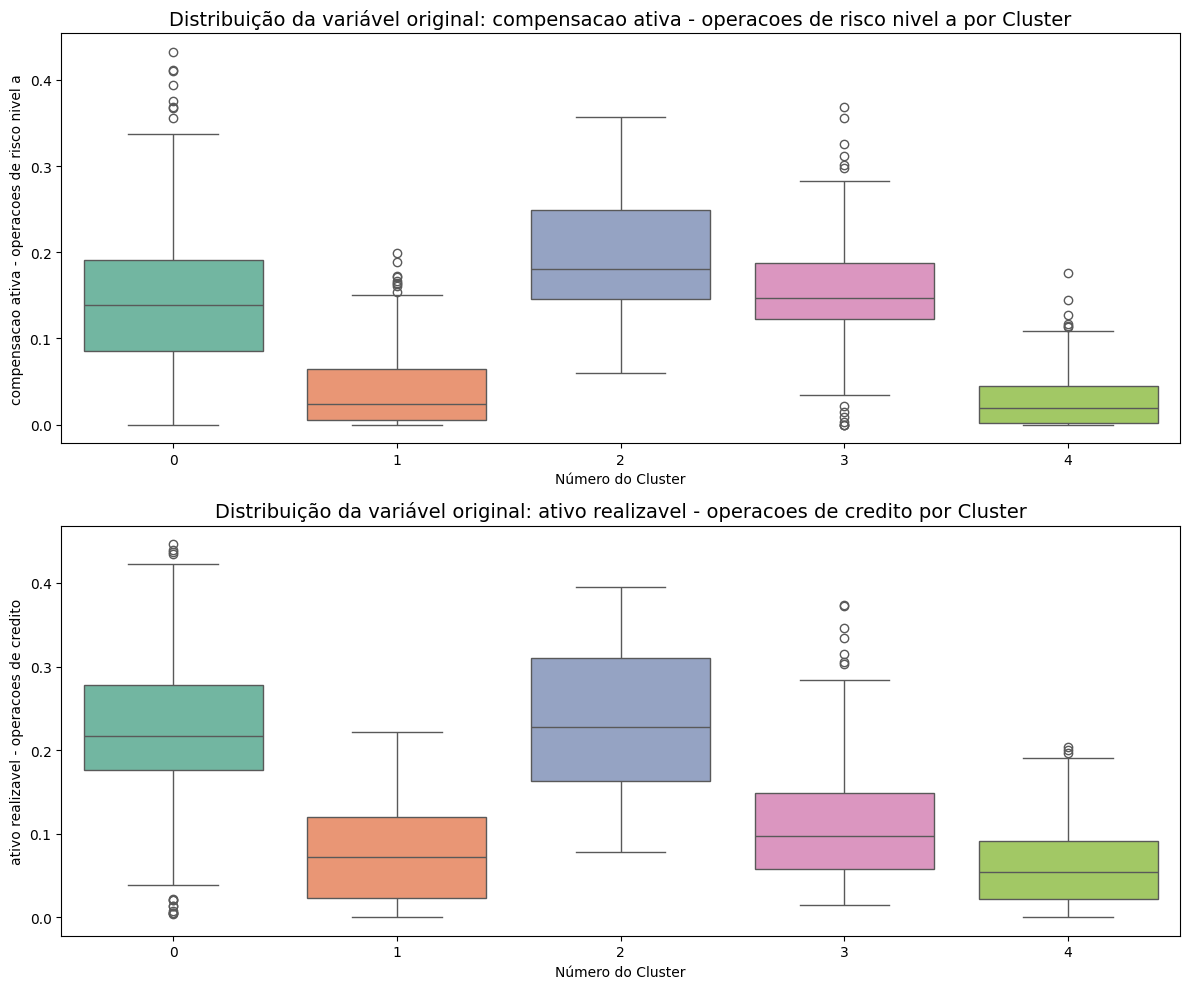

In [20]:
# Teste Kruskal-Wallis (não assume normalidade dos dados)

from scipy.stats import kruskal

def calcular_kruskal_clusters(df, coluna_cluster):
    resultados = []
    
    # Seleciona apenas variáveis numéricas (ignorando a coluna do cluster)
    colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
    colunas_numericas = [col for col in colunas_numericas if col != coluna_cluster]
    
    for coluna in colunas_numericas:
        # Separa a variável em listas, uma para cada cluster, removendo os NaNs
        grupos = [grupo[coluna].dropna() for nome, grupo in df.groupby(coluna_cluster)]
        
        # Como o Kruskal exige pelo menos 2 grupos com dados, fazemos uma checagem
        if len(grupos) > 1:
            stat, p_valor = kruskal(*grupos)
            
            resultados.append({
                'Variavel_Original': coluna,
                'Estatistica_H': stat,
                'P-Valor': p_valor
            })
            
    # Converte para DataFrame e ordena pelas variáveis mais significantes (menor p-valor)
    df_resultados = pd.DataFrame(resultados).sort_values(by='P-Valor')
    
    return df_resultados

# Rodando a função nos nossos dados
kruskal = calcular_kruskal_clusters(clusters, 'Cluster')

# Vamos supor que o teste de Kruskal revelou que 'iip' e 'reser' são as melhores variáveis.
variaveis_top = ['compensacao ativa - operacoes de risco nivel a', 'ativo realizavel - operacoes de credito'] # Substitua pelas variáveis do topo da sua tabela

# Configura o tamanho da figura para caber vários gráficos
plt.figure(figsize=(12, 5 * len(variaveis_top)))

for i, variavel in enumerate(variaveis_top):
    plt.subplot(len(variaveis_top), 1, i+1)
    
    # Plota o boxplot
    sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
    
    plt.title(f'Distribuição da variável original: {variavel} por Cluster', fontsize=14)
    plt.ylabel(variavel)
    plt.xlabel('Número do Cluster')

plt.tight_layout()
plt.show()


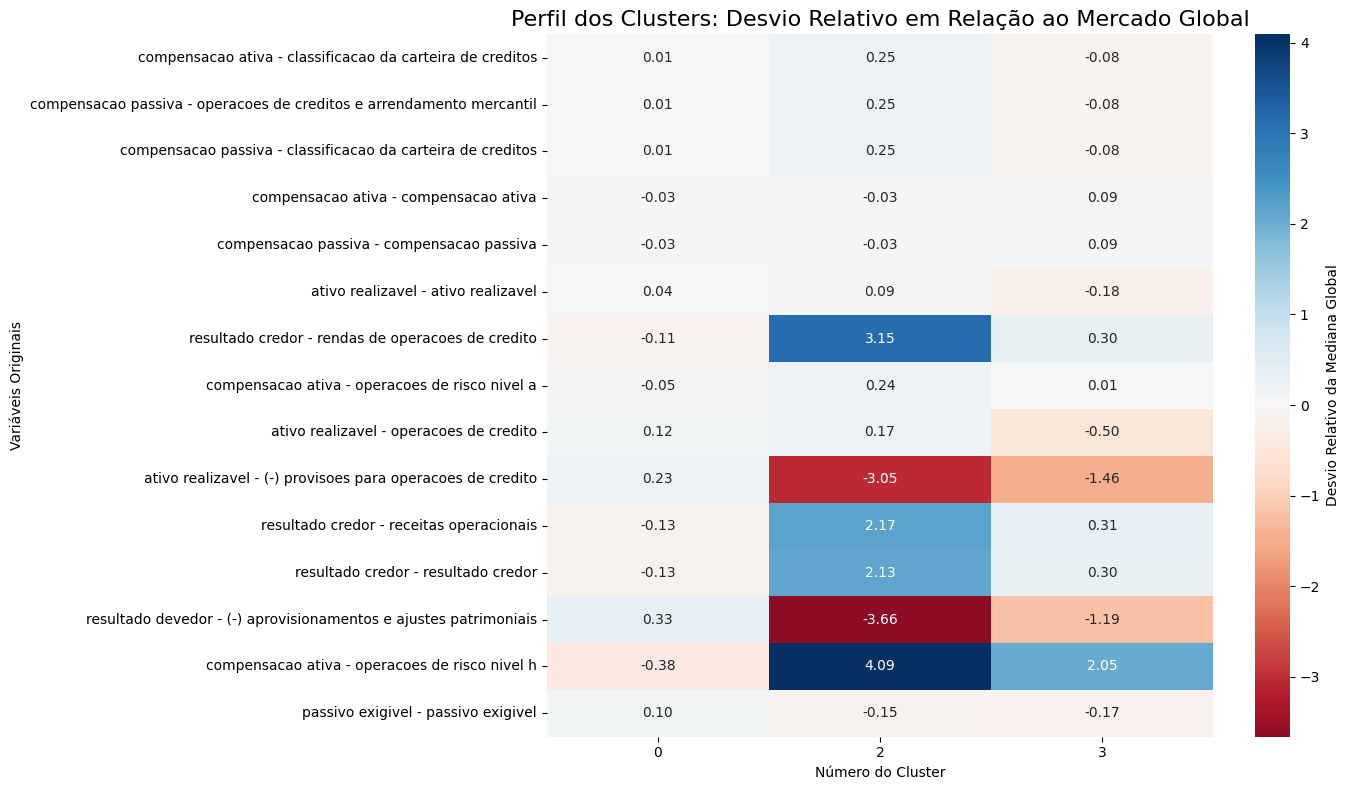

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


clusters_filtrado = clusters[clusters['Cluster'] != 1]
clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 4]
#clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 2]

# 1. Pegue as 15 variáveis mais importantes do seu teste de Kruskal-Wallis
# (Assumindo que df_importancia é o resultado do código anterior)
top_15_variaveis = kruskal['Variavel_Original'].head(15).tolist()

# 2. Calcule a mediana global para essas 15 variáveis
mediana_global = clusters_filtrado[top_15_variaveis].median()

# 3. Calcule a mediana de cada cluster para essas 15 variáveis
mediana_clusters = clusters_filtrado.groupby('Cluster')[top_15_variaveis].median()

# 4. Calcule a variação percentual (ou relativa) do cluster vs o global
# Isso normaliza os dados para o gráfico: 0 = igual ao global, > 0 acima, < 0 abaixo
desvio_relativo = (mediana_clusters - mediana_global) / mediana_global.abs().replace(0, 1e-9) # Evita divisão por zero

# 5. Plota o Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(desvio_relativo.T, # Transposto para variáveis ficarem nas linhas
            cmap='RdBu',       # Vermelho para abaixo da média, Azul para acima
            center=0,          # O branco será exatamente a média global
            annot=True,        # Mostra os números no gráfico
            fmt=".2f",         # 2 casas decimais
            cbar_kws={'label': 'Desvio Relativo da Mediana Global'})

plt.title('Perfil dos Clusters: Desvio Relativo em Relação ao Mercado Global', fontsize=16)
plt.xlabel('Número do Cluster')
plt.ylabel('Variáveis Originais')
plt.tight_layout()
plt.show()

<Axes: xlabel='cluster_proximo_ano', ylabel='Cluster'>

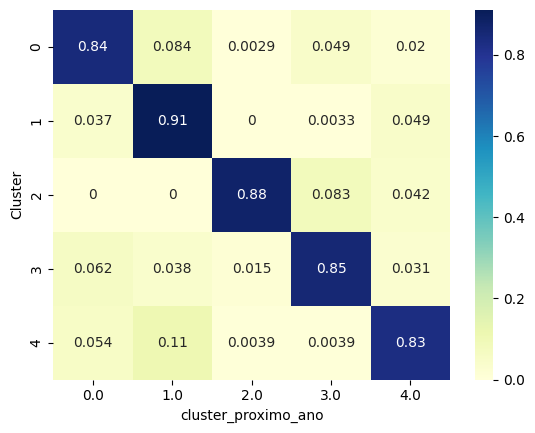

In [22]:
# 1. Criar uma coluna com o cluster do ano seguinte para cada banco
df_sorted = df_fase1.sort_values(['cnpj', 'ano'])
df_sorted['cluster_proximo_ano'] = df_sorted.groupby('cnpj')['Cluster'].shift(-1)

# 2. Criar a matriz de contagem/frequência
matriz_transicao = pd.crosstab(
    df_sorted['Cluster'], 
    df_sorted['cluster_proximo_ano'], 
    normalize='index' # Transforma em porcentagem
)

import seaborn as sns
sns.heatmap(matriz_transicao, annot=True, cmap='YlGnBu')

In [23]:
# Quantos clusters diferentes cada banco já visitou?
mudancas_por_banco = df_fase1.groupby('cnpj')['Cluster'].nunique()

print(f"Bancos que nunca mudaram de cluster: {sum(mudancas_por_banco == 1)}")
print(f"Bancos que já estiveram em 2 ou mais clusters: {sum(mudancas_por_banco > 1)}")

# Ver quem são os bancos que mais mudam
bancos_instaveis = mudancas_por_banco[mudancas_por_banco > 1].index

Bancos que nunca mudaram de cluster: 186
Bancos que já estiveram em 2 ou mais clusters: 95


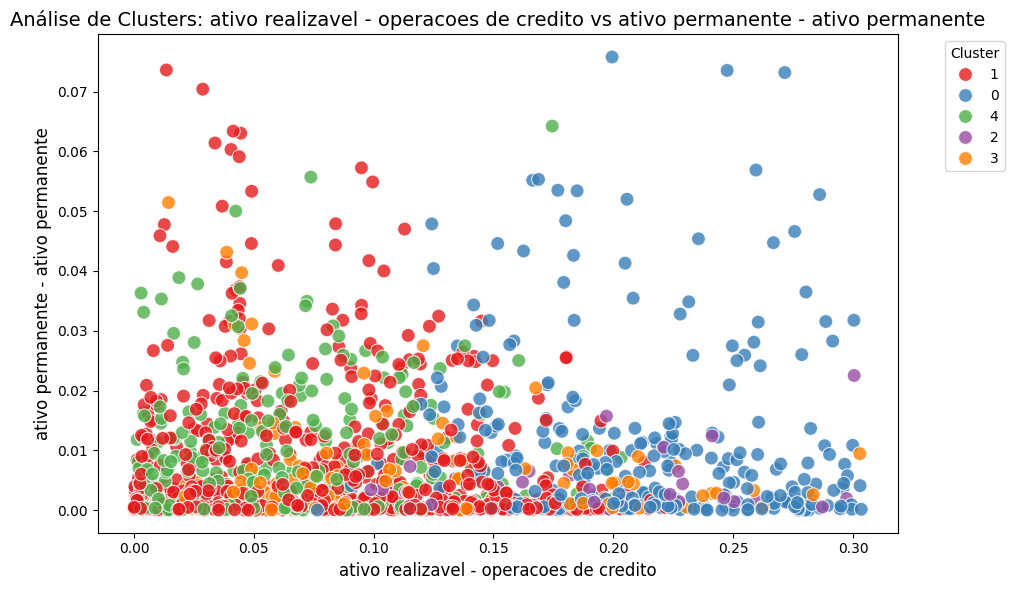

In [24]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd

# 1. Preparação dos Dados
# Supondo que 'df_fase1' seja o seu DataFrame com as proporções (ANTES do Z-score e PCA)
# e que 'final_kmeans' seja o seu modelo K-Means já treinado.

# Criamos uma cópia para não alterar a base df_fase1 acidentalmente
df_viz = df_fase1.copy()

# Adicionamos uma nova coluna com os rótulos dos clusters gerados pelo K-Means
# Transformamos em string (texto) para que o Seaborn entenda como categorias, não como números contínuos
df_viz['Cluster'] = final_kmeans.labels_.astype(str)

# 2. Configuração do Gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura (largura, altura)

# 3. Criando o Gráfico de Dispersão (Scatter Plot)
# Escolha o par de contas do COSIF que você quer cruzar
conta_x = 'ativo realizavel - operacoes de credito'
conta_y = 'ativo permanente - ativo permanente'

# Filtra mantendo apenas quem tem Z-score < 3 nos dois eixos
df_viz = df_viz[
    (np.abs(stats.zscore(df_viz[conta_x])) < 2) &
    (np.abs(stats.zscore(df_viz[conta_y])) < 2)
]

sns.scatterplot(
    data=df_viz, 
    x=conta_x, 
    y=conta_y, 
    hue='Cluster',        # Define a cor baseada na coluna 'Cluster'
    palette='Set1',       # Paleta de cores bem distinta
    s=100,                # Tamanho dos pontos
    alpha=0.8             # Transparência dos pontos (útil se houver sobreposição)
)

# 4. Ajustes estéticos (Títulos e Eixos)
plt.title(f'Análise de Clusters: {conta_x} vs {conta_y}', fontsize=14)
plt.xlabel(conta_x, fontsize=12)
plt.ylabel(conta_y, fontsize=12)

# Move a legenda para fora do gráfico para não cobrir os dados
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Otimiza o layout e exibe o gráfico
plt.tight_layout()
plt.show()

In [25]:
import plotly.express as px

df_2017= df_viz[df_viz['ano'] == 2017]
#df = px.data.X_scaled()
features = ["ativo realizavel - operacoes de credito", "resultado credor - rendas de operacoes de credito", "resultado credor - receitas operacionais", "resultado devedor - (-) despesas operacionais"]

fig = px.scatter_matrix(
    df_2017,
    dimensions=features,
    color="Cluster"
)
fig.update_traces(
    diagonal_visible=False,
    marker=dict(
        size=4,           # Reduz o tamanho (padrão costuma ser 6 ou 8)
        opacity=0.5,      # 40% de opacidade (permite ver através dos pontos)
        line=dict(width=0) # Remove a borda dos pontos para evitar "borrões" escuros
    )
)

fig.update_layout(
    title="Matriz de Dispersão - Safra 2017",
    hovermode='closest'
)

fig.update_traces(diagonal_visible=False)
fig.show()

In [26]:
import plotly.express as px

df_2018= df_viz[(df_viz['ano'] == 2018) & (df_viz['Cluster'] != '1')]
#df = px.data.X_scaled()
features = ["ativo realizavel - operacoes de credito", "resultado credor - rendas de operacoes de credito", "resultado credor - receitas operacionais", "resultado devedor - (-) despesas operacionais"]

fig = px.scatter_matrix(
    df_2018,
    dimensions=features,
    color="Cluster"
)

fig.update_traces(
    diagonal_visible=False,
    marker=dict(
        size=4,           # Reduz o tamanho (padrão costuma ser 6 ou 8)
        opacity=0.5,      # 40% de opacidade (permite ver através dos pontos)
        line=dict(width=0) # Remove a borda dos pontos para evitar "borrões" escuros
    )
)

fig.update_layout(
    title="Matriz de Dispersão - Safra 2018",
    hovermode='closest'
)

fig.update_traces(diagonal_visible=False)
fig.show()

In [27]:
#evolucao_taxonomias = df_filtrado.groupby(['ano', 'taxonomia_agrupada']).size().unstack().fillna(0)
#evolucao_taxonomias.plot(kind='line', stacked=False, marker='', figsize=(16,8))

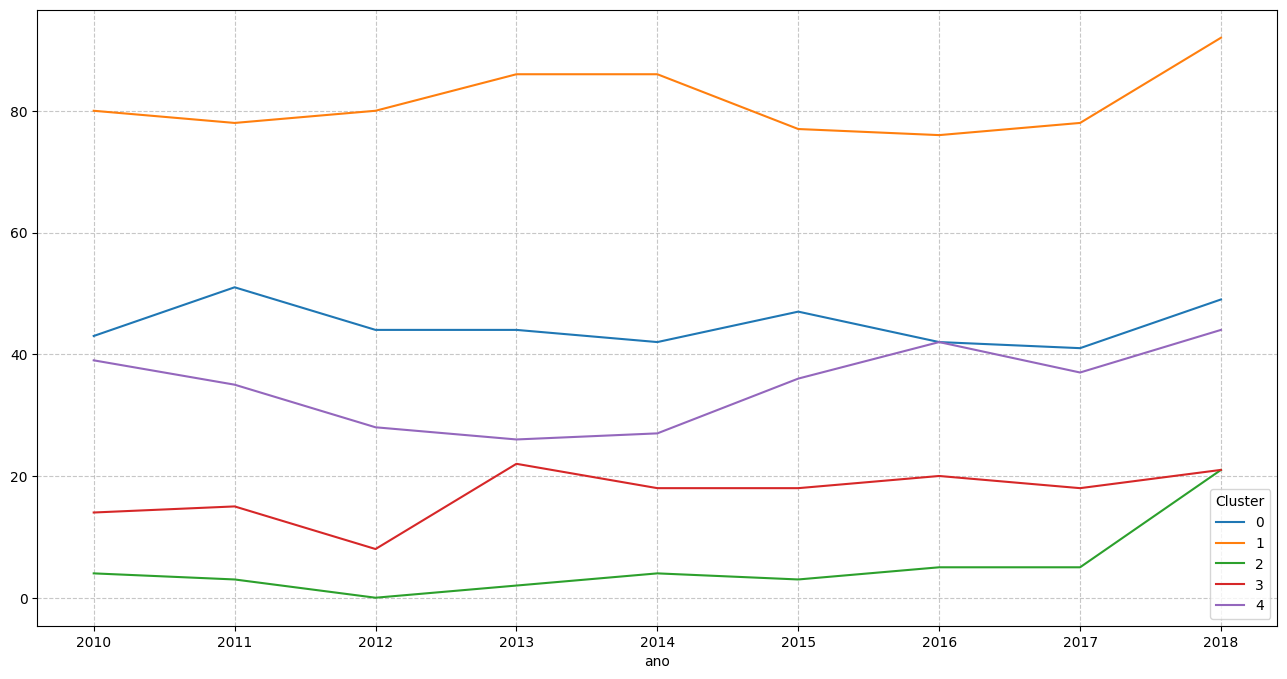

In [28]:
# Ver a evolução da quantidade de bancos em cada cluster por ano
evolucao_clusters = df_fase1.groupby(['ano', 'Cluster']).size().unstack().fillna(0)
evolucao_clusters.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
plt.grid(True, linestyle='--', alpha=0.7)


In [29]:
# Comparando dois clusters

from scipy.stats import mannwhitneyu

def comparar_dois_clusters(df, cluster_A, cluster_B, coluna_cluster='Cluster'):
    resultados = []
    
    # 1. Filtra o DataFrame apenas para os dois clusters escolhidos
    df_A = df[df[coluna_cluster] == cluster_A]
    df_B = df[df[coluna_cluster] == cluster_B]
    
    # 2. Seleciona as colunas numéricas (excluindo a coluna do próprio cluster)
    colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
    colunas_numericas = [col for col in colunas_numericas if col != coluna_cluster]
    
    for coluna in colunas_numericas:
        dados_A = df_A[coluna].dropna()
        dados_B = df_B[coluna].dropna()
        
        # Só calcula se houver dados suficientes nos dois lados
        if len(dados_A) > 0 and len(dados_B) > 0:
            # Teste de Mann-Whitney U
            stat, p_valor = mannwhitneyu(dados_A, dados_B, alternative='two-sided')
            
            # Calcula as medianas e a diferença absoluta entre elas
            mediana_A = dados_A.median()
            mediana_B = dados_B.median()
            diferenca_absoluta = abs(mediana_A - mediana_B)
            
            resultados.append({
                'Variável': coluna,
                f'Mediana_Cluster_{cluster_A}': mediana_A,
                f'Mediana_Cluster_{cluster_B}': mediana_B,
                'Diferença_Absoluta': diferenca_absoluta,
                'P-Valor': p_valor
            })
            
    # Converte para DataFrame
    df_resultados = pd.DataFrame(resultados)
    
    # Filtra apenas o que é estatisticamente significante (P < 0.05)
    df_resultados = df_resultados[df_resultados['P-Valor'] < 0.05]
    
    # Ordena pela maior Diferença Absoluta (o que mais importa para o negócio)
    df_resultados = df_resultados.sort_values(by='Diferença_Absoluta', ascending=False)
    
    return df_resultados

# Exemplo de uso: Comparando o Cluster 1 contra o Cluster 2
# (Use o df original antes da padronização para que as medianas façam sentido em R$ ou %)
batalha_1_vs_2 = comparar_dois_clusters(df_fase1, 1, 2)

print("Top 5 Variáveis que diferenciam o Cluster 1 do Cluster 2:")
print(batalha_1_vs_2.head())

Top 5 Variáveis que diferenciam o Cluster 1 do Cluster 2:
                                             Variável  Mediana_Cluster_1  \
0                                                 ano        2014.000000   
17            compensacao ativa - custodia de valores           0.216132   
53          compensacao passiva - custodia de valores           0.216132   
55  compensacao passiva - classificacao da carteir...           0.088101   
56  compensacao passiva - operacoes de creditos e ...           0.088101   

    Mediana_Cluster_2  Diferença_Absoluta       P-Valor  
0         2017.000000            3.000000  6.106818e-06  
17           0.000000            0.216132  9.769948e-14  
53           0.000000            0.216132  9.769948e-14  
55           0.295512            0.207411  1.312563e-28  
56           0.295512            0.207411  1.312563e-28  


In [30]:
# Market share de crédito por CNPJ e ano

share_individual = df_original_fase1.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

share_individual.columns = ['ano', 'cnpj', 'credito_cnpj']

share_individual['market_share'] = (
    share_individual['credito_cnpj'] / 
    share_individual.groupby('ano')['credito_cnpj'].transform('sum')
)

share_individual = pd.merge(share_individual, df_original_fase1[['ano','cnpj', 'nome', 'taxonomia', 'Cluster']], on=['ano', 'cnpj'], how='left')

coluna_c = share_individual.pop('market_share')
share_individual.insert(6, 'market_share', coluna_c)
coluna_c = share_individual.pop('credito_cnpj')
share_individual.insert(6, 'credito_cnpj', coluna_c)



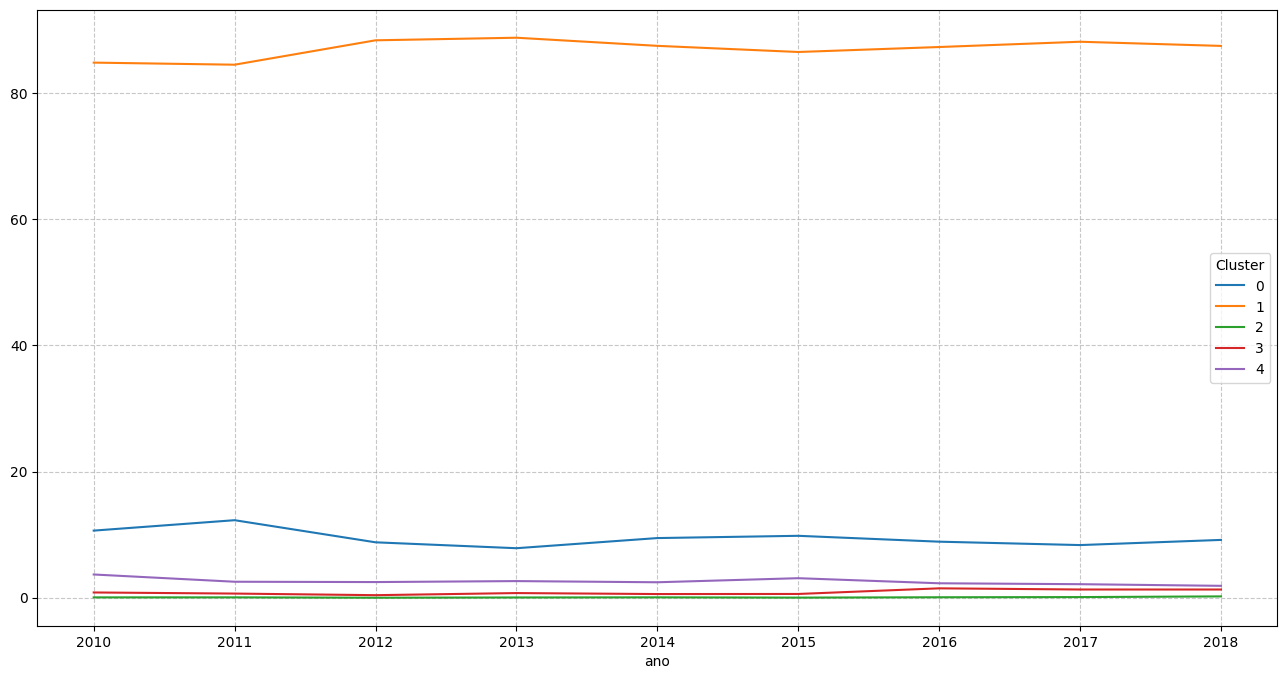

In [31]:
# Calculando o market share de crédito para cada cluster ao longo dos anos

# 1. Agrupar por ano e cluster para somar o crédito
share_df = df_original_fase1.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

# Renomear para clareza
share_df.columns = ['ano', 'Cluster', 'credito_cluster']

# 2. Calcular o total do mercado para cada ano e dividir o valor do cluster por esse total
share_df['market_share'] = (
    share_df['credito_cluster'] / 
    share_df.groupby('ano')['credito_cluster'].transform('sum')
)

# Converter para porcentagem para facilitar a leitura
share_df['market_share_pct'] = share_df['market_share'] * 100

tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

tabela_share.T.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
plt.grid(True, linestyle='--', alpha=0.7)


In [32]:
#clusters = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia', 'taxonomia_agrupada'])
#clusters_media = clusters.groupby('Cluster').mean().T



In [33]:
# Bancos que mudaram para o df_filtrado em 2018
cluster_alvo = 4
bancos_2017 = set(df_filtrado[df_filtrado['ano'] == 2017]['cnpj'])
bancos_2018 = set(df_filtrado[df_filtrado['ano'] == 2018]['cnpj'])

#novos_no_cluster = df_filtrado[(df_filtrado['ano'] == 2018) & (df_filtrado['Cluster'] == cluster_alvo)]
novos_no_cluster = df_filtrado[(df_filtrado['ano'] == 2018)]

migrantes = novos_no_cluster[novos_no_cluster['cnpj'].isin(bancos_2017)]
entrantes_puros = novos_no_cluster[~novos_no_cluster['cnpj'].isin(bancos_2017)]

print(f"Bancos que migraram de outros clusters: {len(migrantes)}")
print(f"Novos bancos que já entraram nesse cluster: {len(entrantes_puros)}")

Bancos que migraram de outros clusters: 175
Novos bancos que já entraram nesse cluster: 52


In [34]:
# 1. Isolar a "Identidade Pré-Choque" (A foto de 2019)
# Ordenamos os dados do df_original_fase1 por banco e por ano.
# Depois, usamos drop_duplicates mantendo a última linha ('last'), que será 2019 (ou o último ano que o banco apareceu antes de 2020)
identidade_pre_crise = df_original_fase1.sort_values(by=['cnpj', 'ano']).drop_duplicates(subset=['cnpj'], keep='last')

# Criamos um "dicionário" (uma Series do Pandas) onde a chave é o CNPJ e o valor é o Cluster
dicionario_clusters = identidade_pre_crise.set_index('cnpj')['Cluster']

# 2. Mapear essa identidade para a base completa (df_original)
# O comando .map() vai olhar o CNPJ no df_original, buscar no dicionário e trazer o Cluster original.
# Se for um banco novo que não estava no dicionário, o Pandas vai preencher com NaN (Nulo).
df_original['Cluster'] = df_original['cnpj'].map(dicionario_clusters)

# 3. Alocar os Bancos Novos para o Cluster 5
# Substituímos todos os NaNs (bancos que surgiram pós-2019) pelo valor 5
df_original['Cluster'] = df_original['Cluster'].fillna(5)

# Converte para inteiro (já que o NaN força a coluna a virar float)
df_original['Cluster'] = df_original['Cluster'].astype(int)

# ==========================================
# TESTE RÁPIDO PARA VALIDAR SE FUNCIONOU
# ==========================================
print("=== Distribuição dos Bancos por Cluster ===")
print(df_original[['cnpj', 'Cluster']].drop_duplicates()['Cluster'].value_counts().sort_index())

=== Distribuição dos Bancos por Cluster ===
Cluster
0     59
1    118
2     23
3     24
4     57
5     82
Name: count, dtype: int64


In [35]:
identidade_pre_crise = df_fase1.sort_values(by=['cnpj', 'ano']).drop_duplicates(subset=['cnpj'], keep='last')

# Criamos um "dicionário" (uma Series do Pandas) onde a chave é o CNPJ e o valor é o Cluster
dicionario_clusters = identidade_pre_crise.set_index('cnpj')['Cluster']

# 2. Mapear essa identidade para a base completa (df_filtrado)
# O comando .map() vai olhar o CNPJ no df_filtrado, buscar no dicionário e trazer o Cluster original.
# Se for um banco novo que não estava no dicionário, o Pandas vai preencher com NaN (Nulo).
df_filtrado['Cluster'] = df_filtrado['cnpj'].map(dicionario_clusters)

# 3. Alocar os Bancos Novos para o Cluster 5
# Substituímos todos os NaNs (bancos que surgiram pós-2019) pelo valor 5
df_filtrado['Cluster'] = df_filtrado['Cluster'].fillna(5)

# Converte para inteiro (já que o NaN força a coluna a virar float)
df_filtrado['Cluster'] = df_filtrado['Cluster'].astype(int)

# ==========================================
# TESTE RÁPIDO PARA VALIDAR SE FUNCIONOU
# ==========================================
print("=== Distribuição dos Bancos por Cluster ===")
print(df_filtrado[['cnpj', 'Cluster']].drop_duplicates()['Cluster'].value_counts().sort_index())

=== Distribuição dos Bancos por Cluster ===
Cluster
0     59
1    118
2     23
3     24
4     57
5     82
Name: count, dtype: int64


Exemplos

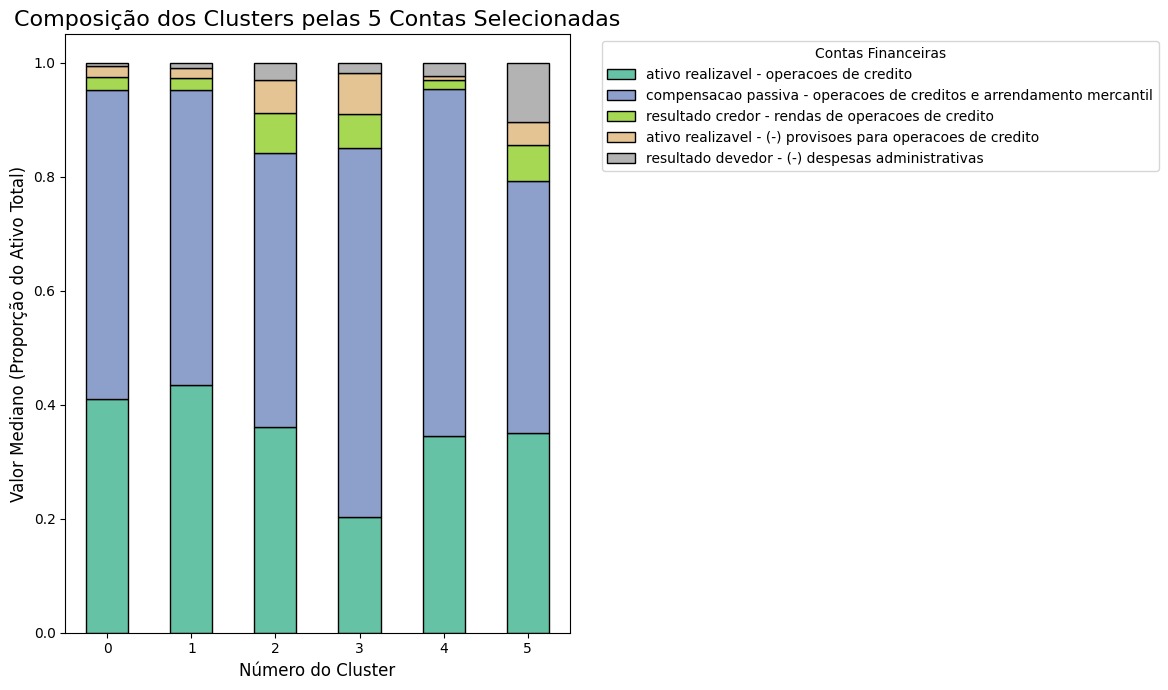

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Defina as 5 variáveis (contas) que você quer analisar
# Substitua pelos nomes exatos das colunas no seu DataFrame
contas_escolhidas = ['ativo realizavel - operacoes de credito', 'compensacao passiva - operacoes de creditos e arrendamento mercantil', 'resultado credor - rendas de operacoes de credito', 'ativo realizavel - (-) provisoes para operacoes de credito', 'resultado devedor - (-) despesas administrativas']
#contas_escolhidas = ['resultado credor - rendas de operacoes de credito', 'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais', 'resultado devedor - (-) despesas administrativas', 'compensacao ativa - operacoes de risco nivel h', 'ativo realizavel - (-) provisoes para operacoes de credito']

# 2. Agrupe os dados pelo Cluster e calcule a Mediana dessas 5 contas
# Usamos a mediana para evitar que outliers distorçam a barra
df_agrupado = df_original.groupby('Cluster')[contas_escolhidas].median().abs()
df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0)

# 3. Gere o Gráfico de Barras Empilhadas
# O parâmetro 'stacked=True' é o que faz a mágica de empilhar
fig, ax = plt.subplots(figsize=(12, 7))
df_agrupado.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')

# 4. Formatação para deixar com cara de apresentação executiva
plt.title('Composição dos Clusters pelas 5 Contas Selecionadas', fontsize=16)
plt.xlabel('Número do Cluster', fontsize=12)
plt.ylabel('Valor Mediano (Proporção do Ativo Total)', fontsize=12)

# Rotaciona os números do eixo X para ficarem retos
plt.xticks(rotation=0) 

# Move a legenda para fora do gráfico para não tampar as barras
plt.legend(title='Contas Financeiras', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajusta o layout para a legenda não ser cortada ao salvar
plt.tight_layout() 

plt.show()

In [37]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_2023= df_filtrado[df_filtrado['ano'] == 2023]
df_2023 = df_2023.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'], axis=1)
df_2023 = df_2023[['ativo realizavel - operacoes de credito', 'compensacao ativa - compensacao ativa', 'passivo exigivel - passivo exigivel']]
df_2023.columns = df_2023.columns.astype(str) 
df_2023 = scaler.fit_transform(df_2023) 

# ====================================================================
# 1. GERAÇÃO DE DADOS SINTÉTICOS (Uma nuvem 3D alongada)
# ====================================================================
np.random.seed(42)
n_samples = 150
x = df_2023[:, 0]
y = df_2023[:, 1]
z = df_2023[:, 2]

df_3d = pd.DataFrame({'Ativo': x, 'Passivo': y, 'Provisão': z})

# ====================================================================
# 2. APLICAÇÃO DO PCA (Para encontrar as direções principais)
# ====================================================================
# É obrigatório padronizar para centralizar na origem (0,0,0)
dados_padronizados = StandardScaler().fit_transform(df_3d)

# Treinamos o PCA para 2 componentes (o plano)
pca = PCA(n_components=2)
pca.fit(dados_padronizados)

# Os autovetores (PC1 e PC2) definem a direção do plano
componentes = pca.components_
# Os autovalores (explained_variance_) dizem o tamanho da variação
relevancia = pca.explained_variance_

# ====================================================================
# 3. CONSTRUÇÃO MATEMÁTICA DO PLANO PCA
# ====================================================================
# Criamos uma grade (grid) para desenhar o plano
limite = 3
u = np.linspace(-limite, limite, 10)
v = np.linspace(-limite, limite, 10)
U, V = np.meshgrid(u, v)

# A equação matemática do plano definido por PC1 e PC2
# Usamos o produto vetorial (cross product) para achar o vetor normal ao plano
normal_vetor = np.cross(componentes[0], componentes[1])
d = 0 # Plano passa pela origem (0,0,0)
W = (-normal_vetor[0] * U - normal_vetor[1] * V - d) / normal_vetor[2]

# ====================================================================
# 4. VISUALIZAÇÃO INTERATIVA COM PLOTLY
# ====================================================================
fig = go.Figure()

# A. Adicionar os pontos de dados originais (Scatter3d)
fig.add_trace(go.Scatter3d(
    x=dados_padronizados[:,0], y=dados_padronizados[:,1], z=dados_padronizados[:,2],
    mode='markers',
    marker=dict(size=4, color='rgba(0, 102, 204, 0.6)', line=dict(color='black', width=0.5)),
    name='Instituições (Dados 3D Centralizados)'
))

# B. Adicionar o Plano PCA (Surface)
fig.add_trace(go.Surface(
    x=U, y=V, z=W,
    colorscale='Reds',
    showscale=False,
    opacity=0.4,
    name='Plano PCA (Subespaço 2D Ideal)'
))

# C. Adicionar os vetores dos Componentes Principais (PC1 e PC2)
for i, comp in enumerate(componentes):
    # Multiplicamos o vetor pelo autovalor para ele ter o tamanho da variância que explica
    tamanho = np.sqrt(relevancia[i])
    fig.add_trace(go.Scatter3d(
        x=[0, comp[0]*tamanho], y=[0, comp[1]*tamanho], z=[0, comp[2]*tamanho],
        mode='lines+text',
        line=dict(color='black', width=6),
        name=f'Vetor PC{i+1}'
    ))

# D. Ajustes de Layout (Títulos e Eixos)
fig.update_layout(
    title='Projeção 3D vs Plano PCA 2D',
    scene=dict(
        xaxis=dict(title='operacoes de credito'),
        yaxis=dict(title='compensacao ativa'),
        zaxis=dict(title='passivo exigivel'),
        aspectmode='cube' # Mantém as proporções reais dos desvios padrões
    ),
    width=700, height=500,
    margin=dict(l=0, r=0, b=0, t=50)
)

# E. Exibir o gráfico (irá abrir no seu navegador ou notebook)
fig.show()

In [38]:
# Dados de volatilidade de taxas de juros

conn = sqlite3.connect('dados/banking.db')

query = """
SELECT
    *
FROM
    media_volatilidade_anual
"""

taxas_termo = pd.read_sql_query(query, conn)

conn.close()

taxas_termo['ano'] = taxas_termo['ano'].astype(int)

#vol = taxas_termo.groupby(pd.Grouper(key='data', freq='Y'))['taxa'].agg(['std_3m', 'mean_3m'])
#std.rename(columns={'std': 'std_3m', 'mean': 'mean_3m'}, inplace=True)



In [39]:
model  = df_filtrado[['ano', 'cnpj', 'nome', 'taxonomia','Cluster']].copy()
df_original = df_original.fillna(0)

# Net Interest Margin (nim)

#model['nim'] = 100 * (df[['resultado credor - receitas operacionais', 'resultado devedor - (-) despesas de captacao']].sum(axis=1) / df_original['ativo realizavel - ativo realizavel'])

model['nim'] = 100 * (df_original['resultado credor - receitas operacionais'] - df_original['resultado devedor - (-) despesas de captacao'].abs()) / df_original['ativo realizavel - ativo realizavel']

# Market Structure (lerner/herf)

share_individual['share_quadrado'] = share_individual['market_share'] ** 2
hhi_anual = share_individual.groupby('ano')['share_quadrado'].sum().reset_index()
hhi_anual.columns = ['ano', 'hhi']
model = model.reset_index()

model = pd.merge(
    model,
    hhi_anual,
    on=['ano'],
    how='left'
)
model = model.set_index('index')
model.index.name = None
model['hhi'] = 100 * model['hhi']

# Operating Costs (aoc)

model['aoc'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['compensacao ativa - total geral do ativo'])

# Degree of risk aversion (riskaver)

model['riskaver'] = 100 * (df_original['patrimonio liquido - patrimonio liquido'] / df_original['compensacao ativa - total geral do ativo'])

# Volatility of market interest rates (sd*)

model = model.reset_index()
model = pd.merge(
    model,
    taxas_termo,
    on=['ano'],
    how='left'
)
model = model.set_index('index')
model.index.name = None

# Credit Risk (crerisk)

model['crerisk'] = 100 * (df_original['ativo realizavel - (-) provisoes para operacoes de credito'].abs() / df_original['ativo realizavel - operacoes de credito'])

# Interaction between credit risk and market risk (sd*crerisk)

model['sd_3m*crerisk'] = model['sd_annual_3m'] * model['crerisk'] / 100
model['sd_1ano*crerisk'] = model['sd_annual_1ano'] * model['crerisk'] / 100
model['sd_2anos*crerisk'] = model['sd_annual_2anos'] * model['crerisk'] / 100
model['sd_3anos*crerisk'] = model['sd_annual_3anos'] * model['crerisk'] / 100
model['sd_5anos*crerisk'] = model['sd_annual_5anos'] * model['crerisk'] / 100

# Average size of operations/volume of loans (size)

model['size'] = np.log10(df_original['ativo realizavel - operacoes de credito'])

# Implicit interest payments (iip)

model['iip'] = 100 * ((df_original['resultado devedor - (-) despesas operacionais'].abs() - df_original['resultado credor - rendas de prestacao de servicos']) / df_original['compensacao ativa - total geral do ativo'])

# Opportunity costs of bank reserves (reser)

model['reser'] = 100 * (df[['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez']].sum(axis=1) / df_original['compensacao ativa - total geral do ativo'])

#model['reser'] = 100 * ((df_original['ativo realizavel - disponibilidades'] + df_original['ativo realizavel - aplicacoes interfinanceiras de liquidez']) / df_original['compensacao ativa - total geral do ativo'])

# Quality of management (ef)

model['ef'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['resultado credor - receitas operacionais'])

# Time dummies

dummies_tempo = pd.get_dummies(model['ano'], drop_first=True)
dummies_tempo = dummies_tempo.astype(int)
model = pd.concat([model, dummies_tempo], axis=1)


In [40]:
# 1. Centralizando as variáveis contínuas
model['crerisk_c'] = model['crerisk'] - model['crerisk'].mean()
model['sd_3anos_c'] = model['sd_annual_3anos'] - model['sd_annual_3anos'].mean()
model['sd_3m_c'] = model['sd_annual_3m'] - model['sd_annual_3m'].mean()

# 2. Criando as interações centralizadas
model['interacao_3anos'] = model['crerisk_c'] * model['sd_3anos_c']
model['interacao_3m'] = model['crerisk_c'] * model['sd_3m_c']

In [41]:
contagem_zeros = (model == 0).sum()

print(contagem_zeros)

ano                    0
cnpj                   0
nome                   0
taxonomia              0
Cluster              622
nim                    0
hhi                    0
aoc                    0
riskaver               0
sd_annual_3m           0
sd_annual_1ano         0
sd_annual_2anos        0
sd_annual_3anos        0
sd_annual_5anos        0
crerisk              101
sd_3m*crerisk        101
sd_1ano*crerisk      101
sd_2anos*crerisk     101
sd_3anos*crerisk     101
sd_5anos*crerisk     101
size                   0
iip                    0
reser                 23
ef                     0
2011                2968
2012                2990
2013                2970
2014                2973
2015                2969
2016                2965
2017                2971
2018                2923
2019                2923
2020                2917
2021                2907
2022                2897
2023                2882
2024                2875
crerisk_c              0
sd_3anos_c             0


In [42]:
model = model.fillna(0)

cluster0 = model[model['Cluster'] == 0]
cluster1 = model[model['Cluster'] == 1]
cluster2 = model[model['Cluster'] == 2]
cluster3 = model[model['Cluster'] == 3]
cluster4 = model[model['Cluster'] == 4]

In [43]:
# Regressão
import statsmodels.api as sm

colunas_X_originais = ['hhi', 'sd_3m_c', 'sd_3anos_c', 'crerisk_c', 'interacao_3m','interacao_3anos', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']
colunas_X = colunas_X_originais + list(dummies_tempo.columns)
X = cluster0[colunas_X_originais]
y = cluster0['nim']

stage1 = sm.OLS(y, sm.add_constant(X)).fit()
results_stage1 = stage1
print(results_stage1.summary())

spread_estimado = cluster0[['ano', 'cnpj', 'nome']]
spread_estimado['spread_estimado'] = results_stage1.predict()
#spread_estimado['spread_puro'] = results_stage1.params['const'] + cluster0[dummies_tempo.columns].dot(results_stage1.params[dummies_tempo.columns])


                            OLS Regression Results                            
Dep. Variable:                    nim   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     18.51
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.43e-34
Time:                        00:29:58   Log-Likelihood:                -2722.0
No. Observations:                 622   AIC:                             5470.
Df Residuals:                     609   BIC:                             5528.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              56.6896     11.609     

/tmp/ipykernel_469282/3390700289.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spread_estimado['spread_estimado'] = results_stage1.predict()


In [44]:
X = cluster1[colunas_X]
y = cluster1['nim']

stage1 = sm.OLS(y, sm.add_constant(X)).fit()
results_stage1 = stage1
print(results_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:                    nim   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     57.24
Date:                Sat, 16 May 2026   Prob (F-statistic):          1.07e-177
Time:                        00:29:58   Log-Likelihood:                -4204.6
No. Observations:                1297   AIC:                             8457.
Df Residuals:                    1273   BIC:                             8581.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.8723      1.405     

In [45]:
X = cluster2[colunas_X]
y = cluster2['nim']

stage1 = sm.OLS(y, sm.add_constant(X)).fit()
results_stage1 = stage1
print(results_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:                    nim   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     21.86
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.87e-36
Time:                        00:29:58   Log-Likelihood:                -523.33
No. Observations:                 171   AIC:                             1095.
Df Residuals:                     147   BIC:                             1170.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              20.1630      5.485     

In [46]:
X = cluster3[colunas_X]
y = cluster3['nim']

stage1 = sm.OLS(y, sm.add_constant(X)).fit()
results_stage1 = stage1
print(results_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:                    nim   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     36.20
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.21e-64
Time:                        00:29:58   Log-Likelihood:                -644.97
No. Observations:                 262   AIC:                             1338.
Df Residuals:                     238   BIC:                             1424.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.3923      3.414     

In [47]:
X = cluster4[colunas_X]
y = cluster4['nim']

stage1 = sm.OLS(y, sm.add_constant(X)).fit()
results_stage1 = stage1
print(results_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:                    nim   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     73.25
Date:                Sat, 16 May 2026   Prob (F-statistic):          1.27e-151
Time:                        00:29:58   Log-Likelihood:                -2065.2
No. Observations:                 580   AIC:                             4178.
Df Residuals:                     556   BIC:                             4283.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.3993      4.159     

In [48]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

# 1. Preparação dos Dados (Essencial)
# Modelos de painel no Python EXIGEM que o índice do DataFrame seja duplo: (Entidade, Tempo)
# Substitua 'id_banco' pelo nome real da coluna que identifica as instituições no seu banco de dados
df_panel = model.set_index(['cnpj', 'ano'])

# 2. Definição das Variáveis (Já removendo a multicolinearidade severa)
# DICA: Removi os vários sd_annual e mantive apenas um de curto (3m) e um de longo (5anos)
# Removi as variáveis 'ano' (pois o painel de efeitos fixos bidirecionais já cuida do tempo)
variaveis_explicativas = ['sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

X = df_panel[variaveis_explicativas]
X = sm.add_constant(X) # Adiciona o intercepto
Y = df_panel['nim']

# 3. Rodando o Modelo de Efeitos Fixos (Entity Effects e Time Effects)
# Incluímos efeitos de entidade (banco) e efeitos de tempo (substitui suas dummies de anos)
modelo_fe = PanelOLS(Y, X, entity_effects=True, time_effects=False)

# Usamos 'cov_type='clustered'' para erros padrão robustos (corrige autocorrelação nos bancos)
resultados_fe = modelo_fe.fit(cov_type='clustered', cluster_entity=True)
print("=== RESULTADOS EFEITOS FIXOS (FE) ===")
print(resultados_fe)

# 4. Rodando o Modelo de Efeitos Aleatórios (RE)
modelo_re = RandomEffects(Y, X)
resultados_re = modelo_re.fit()
print("\n=== RESULTADOS EFEITOS ALEATÓRIOS (RE) ===")
print(resultados_re)

=== RESULTADOS EFEITOS FIXOS (FE) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.3344
Estimator:                   PanelOLS   R-squared (Between):              0.5097
No. Observations:                3150   R-squared (Within):               0.3344
Date:                Sat, May 16 2026   R-squared (Overall):              0.4113
Time:                        00:29:58   Log-likelihood                -1.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      155.11
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                  F(9,2778)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):          

In [49]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# 1. Definir a identidade (A dummy do Cluster 0)
# 'Cluster' deve ser aquele carimbo fixo que você calculou com dados pré-choque
df_panel['is_cluster0'] = (df_panel['Cluster'] == 0).astype(int)

# 2. Definir o período do Choque (Exemplo: Pandemia)
df_panel['pos_choque'] = (df_panel.index.get_level_values('ano') >= 2020).astype(int)

# 3. Criar a variável de Efeito Heterogêneo (A Interação)
# Isso será 1 APENAS para os bancos do Cluster 0, DURANTE e APÓS 2020
df_panel['Cluster0_X_choque'] = df_panel['is_cluster0'] * df_panel['pos_choque']

colunas_X_originais = ['Cluster0_X_choque', 'hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

# 4. Selecionar Variáveis
X = df_panel[colunas_X_originais]
X = sm.add_constant(X)
Y = df_panel['nim']

# 5. Rodar o TWFE
modelo_twfe = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)

print(resultados_twfe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.3201
Estimator:                   PanelOLS   R-squared (Between):              0.4941
No. Observations:                3150   R-squared (Within):               0.3295
Date:                Sat, May 16 2026   R-squared (Overall):              0.4040
Time:                        00:29:59   Log-likelihood                -1.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      144.58
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                  F(9,2764)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             15.556
                            

/tmp/ipykernel_469282/1608047193.py:25: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)


In [53]:
# 1. Definir a identidade (A dummy do Cluster 1)
# 'Cluster' deve ser aquele carimbo fixo que você calculou com dados pré-choque
df_panel['is_cluster1'] = (df_panel['Cluster'] == 1).astype(int)

# 2. Definir o período do Choque (Exemplo: Pandemia)
df_panel['pos_choque'] = (df_panel.index.get_level_values('ano') >= 2020).astype(int)

# 3. Criar a variável de Efeito Heterogêneo (A Interação)
# Isso será 1 APENAS para os bancos do Cluster 0, DURANTE e APÓS 2020
df_panel['Cluster1_X_choque'] = df_panel['is_cluster1'] * df_panel['pos_choque']

colunas_X_originais = ['Cluster1_X_choque', 'hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

# 4. Selecionar Variáveis
X = df_panel[colunas_X_originais]
X = sm.add_constant(X)
Y = df_panel['nim']

# 5. Rodar o TWFE
modelo_twfe = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)

print(resultados_twfe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.3205
Estimator:                   PanelOLS   R-squared (Between):              0.4984
No. Observations:                3150   R-squared (Within):               0.3306
Date:                Sat, May 16 2026   R-squared (Overall):              0.4066
Time:                        00:31:35   Log-likelihood                -1.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      144.84
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                  F(9,2764)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             15.997
                            

/tmp/ipykernel_469282/1312741782.py:21: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)


In [50]:
# 1. Definir a identidade (A dummy do Cluster 2)
# 'Cluster' deve ser aquele carimbo fixo que você calculou com dados pré-choque
df_panel['is_cluster2'] = (df_panel['Cluster'] == 2).astype(int)

# 2. Definir o período do Choque (Exemplo: Pandemia)
df_panel['pos_choque'] = (df_panel.index.get_level_values('ano') >= 2020).astype(int)

# 3. Criar a variável de Efeito Heterogêneo (A Interação)
# Isso será 1 APENAS para os bancos do Cluster 0, DURANTE e APÓS 2020
df_panel['Cluster2_X_choque'] = df_panel['is_cluster2'] * df_panel['pos_choque']

colunas_X_originais = ['Cluster2_X_choque', 'hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

# 4. Selecionar Variáveis
X = df_panel[colunas_X_originais]
X = sm.add_constant(X)
Y = df_panel['nim']

# 5. Rodar o TWFE
modelo_twfe = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)

print(resultados_twfe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.3219
Estimator:                   PanelOLS   R-squared (Between):              0.5027
No. Observations:                3150   R-squared (Within):               0.3310
Date:                Sat, May 16 2026   R-squared (Overall):              0.4098
Time:                        00:29:59   Log-likelihood                -1.067e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      145.79
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                  F(9,2764)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             18.438
                            

/tmp/ipykernel_469282/2840070947.py:21: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)


In [51]:
# 1. Definir a identidade (A dummy do Cluster 3)
# 'Cluster' deve ser aquele carimbo fixo que você calculou com dados pré-choque
df_panel['is_cluster3'] = (df_panel['Cluster'] == 3).astype(int)

# 2. Definir o período do Choque (Exemplo: Pandemia)
df_panel['pos_choque'] = (df_panel.index.get_level_values('ano') >= 2020).astype(int)

# 3. Criar a variável de Efeito Heterogêneo (A Interação)
# Isso será 1 APENAS para os bancos do Cluster 0, DURANTE e APÓS 2020
df_panel['Cluster3_X_choque'] = df_panel['is_cluster3'] * df_panel['pos_choque']

colunas_X_originais = ['Cluster3_X_choque', 'hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

# 4. Selecionar Variáveis
X = df_panel[colunas_X_originais]
X = sm.add_constant(X)
Y = df_panel['nim']

# 5. Rodar o TWFE
modelo_twfe = PanelOLS(Y, X, entity_effects=True, time_effects=True, drop_absorbed=True)
resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)

print(resultados_twfe)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.3203
Estimator:                   PanelOLS   R-squared (Between):              0.4951
No. Observations:                3150   R-squared (Within):               0.3296
Date:                Sat, May 16 2026   R-squared (Overall):              0.4044
Time:                        00:29:59   Log-likelihood                -1.068e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      144.73
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                  F(9,2764)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             15.597
                            

/tmp/ipykernel_469282/1709819127.py:21: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_twfe = modelo_twfe.fit(cov_type='clustered', cluster_entity=True)


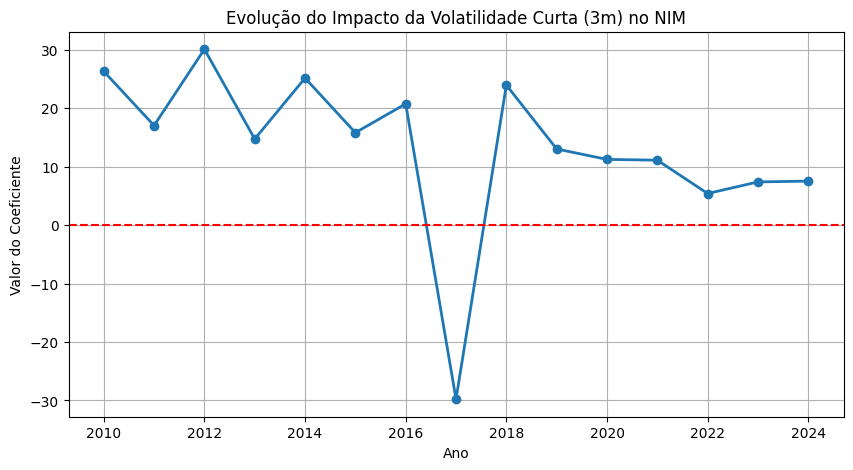

In [52]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Variáveis que queremos testar
vars_explicativas = ['sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'interacao_3m','interacao_3anos', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']
# 2. Dicionário para guardar os resultados de cada ano
historico_coeficientes = []

# 3. Loop rodando a regressão para cada ano separadamente
anos = sorted(cluster0['ano'].unique())
for ano in anos:
    # Filtra os dados apenas para o ano atual
    cluster0_ano = cluster0[cluster0['ano'] == ano].dropna(subset=vars_explicativas + ['nim'])
    
    Y_ano = cluster0_ano['nim']
    X_ano = sm.add_constant(cluster0_ano[vars_explicativas])
    
    # Roda um OLS simples (cross-section) para aquele ano
    modelo = sm.OLS(Y_ano, X_ano).fit(cov_type='HC1') # HC1 para erros robustos
    
    # Salva o ano e os coeficientes
    resultado = {'ano': ano}
    resultado.update(modelo.params.to_dict())
    historico_coeficientes.append(resultado)

# 4. Converte para DataFrame para facilitar a visualização
cluster0_coefs = pd.DataFrame(historico_coeficientes).set_index('ano')

# 5. Plota a evolução temporal de uma variável (ex: sd_annual_3m)
plt.figure(figsize=(10, 5))
plt.plot(cluster0_coefs.index, cluster0_coefs['iip'], marker='o', linewidth=2)
plt.axhline(0, color='red', linestyle='--') # Linha do zero
plt.title('Evolução do Impacto da Volatilidade Curta (3m) no NIM')
plt.ylabel('Valor do Coeficiente')
plt.xlabel('Ano')
plt.grid(True)
plt.show()